## Basic Stock Trading

In [26]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

In [ ]:
tickerSymbol = 'JBLU'

In [ ]:
tickerData = yf.Ticker(tickerSymbol)

In [ ]:
tickerDf = tickerData.history(interval='1d', start='2019-1-1', end='2020-4-10')
tickerDf.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-01-02 00:00:00-05:00,15.800000,16.280001,15.660000,16.200001,2589400,0.0,0.0
2019-01-03 00:00:00-05:00,16.010000,16.070000,15.290000,15.930000,6430800,0.0,0.0
2019-01-04 00:00:00-05:00,16.139999,16.780001,16.080000,16.549999,4754100,0.0,0.0
2019-01-07 00:00:00-05:00,16.639999,16.940001,16.400000,16.690001,3189000,0.0,0.0
2019-01-08 00:00:00-05:00,16.860001,16.930000,16.629999,16.850000,3921900,0.0,0.0


In [30]:
priceData = tickerDf.Open
priceData.head()

Date
2019-01-02 00:00:00-05:00    15.800000
2019-01-03 00:00:00-05:00    16.010000
2019-01-04 00:00:00-05:00    16.139999
2019-01-07 00:00:00-05:00    16.639999
2019-01-08 00:00:00-05:00    16.860001
Name: Open, dtype: float64

In [31]:
priceData = priceData.asfreq(pd.infer_freq(priceData.index))
priceData.head()

Date
2019-01-02 00:00:00-05:00    15.800000
2019-01-03 00:00:00-05:00    16.010000
2019-01-04 00:00:00-05:00    16.139999
2019-01-05 00:00:00-05:00          NaN
2019-01-06 00:00:00-05:00          NaN
Freq: D, Name: Open, dtype: float64

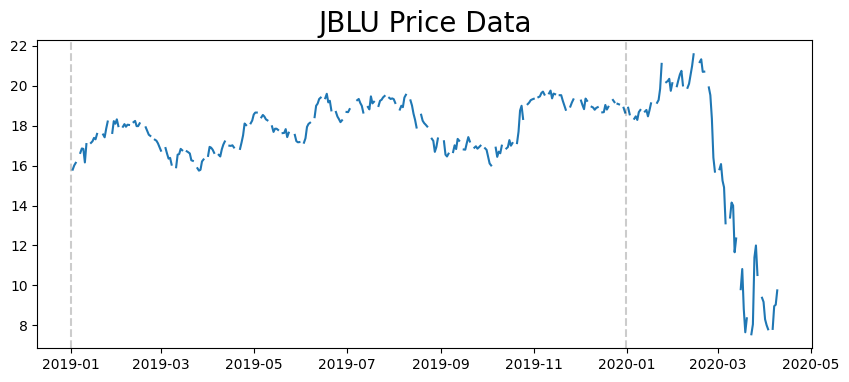

In [32]:
plt.figure(figsize=(10,4))
plt.plot(priceData)
for year in range(priceData.index[0].year, priceData.index[-1].year+1):
    plt.axvline(datetime(year,1,1), color='k', linestyle='--', alpha=0.2)
plt.title("%s Price Data"%tickerSymbol, fontsize=20)
plt.show()

### Basic Buying Protocol:


- Buy if stock increasing for b consecutive days

### Basic Selling Protocols:

- Sell if stock decreasing for s consecutive days (and we've made a profit)

In [ ]:
def get_buying_selling_days(price_data, b, s):
    
    pct_change = price_data.pct_change()[1:]
    
    def buying_condition(sub_series):
        return (sub_series > 0).all()
    
    def selling_condition(sub_series):
        return (sub_series < 0).all()
    
    buying_days = pct_change.rolling(b).apply(buying_condition)
    
    potential_selling_days = pct_change.rolling(s).apply(selling_condition)
    
    return {'buying_days': buying_days, 'potential_selling_days': potential_selling_days}

In [34]:
info_dict = get_buying_selling_days(priceData, 4, 1)
info_dict

C:\Users\rt\AppData\Local\Temp\ipykernel_15884\3708491760.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  pct_change = price_data.pct_change()[1:]


{'buying_days': Date
 2019-01-03 00:00:00-05:00    NaN
 2019-01-04 00:00:00-05:00    NaN
 2019-01-05 00:00:00-05:00    NaN
 2019-01-06 00:00:00-05:00    0.0
 2019-01-07 00:00:00-05:00    0.0
                             ... 
 2020-04-05 00:00:00-04:00    0.0
 2020-04-06 00:00:00-04:00    0.0
 2020-04-07 00:00:00-04:00    0.0
 2020-04-08 00:00:00-04:00    0.0
 2020-04-09 00:00:00-04:00    1.0
 Freq: D, Name: Open, Length: 463, dtype: float64,
 'potential_selling_days': Date
 2019-01-03 00:00:00-05:00    0.0
 2019-01-04 00:00:00-05:00    0.0
 2019-01-05 00:00:00-05:00    0.0
 2019-01-06 00:00:00-05:00    0.0
 2019-01-07 00:00:00-05:00    0.0
                             ... 
 2020-04-05 00:00:00-04:00    0.0
 2020-04-06 00:00:00-04:00    0.0
 2020-04-07 00:00:00-04:00    0.0
 2020-04-08 00:00:00-04:00    0.0
 2020-04-09 00:00:00-04:00    0.0
 Freq: D, Name: Open, Length: 463, dtype: float64}

In [35]:
buying_days = info_dict['buying_days']
buying_days

Date
2019-01-03 00:00:00-05:00    NaN
2019-01-04 00:00:00-05:00    NaN
2019-01-05 00:00:00-05:00    NaN
2019-01-06 00:00:00-05:00    0.0
2019-01-07 00:00:00-05:00    0.0
                            ... 
2020-04-05 00:00:00-04:00    0.0
2020-04-06 00:00:00-04:00    0.0
2020-04-07 00:00:00-04:00    0.0
2020-04-08 00:00:00-04:00    0.0
2020-04-09 00:00:00-04:00    1.0
Freq: D, Name: Open, Length: 463, dtype: float64

In [36]:
potential_selling_days = info_dict['potential_selling_days']
potential_selling_days

Date
2019-01-03 00:00:00-05:00    0.0
2019-01-04 00:00:00-05:00    0.0
2019-01-05 00:00:00-05:00    0.0
2019-01-06 00:00:00-05:00    0.0
2019-01-07 00:00:00-05:00    0.0
                            ... 
2020-04-05 00:00:00-04:00    0.0
2020-04-06 00:00:00-04:00    0.0
2020-04-07 00:00:00-04:00    0.0
2020-04-08 00:00:00-04:00    0.0
2020-04-09 00:00:00-04:00    0.0
Freq: D, Name: Open, Length: 463, dtype: float64

In [ ]:
df_stocks = pd.DataFrame(index = buying_days.index)
df_stocks.head()

""
Date
2019-01-03 00:00:00-05:00
2019-01-04 00:00:00-05:00
2019-01-05 00:00:00-05:00
2019-01-06 00:00:00-05:00
2019-01-07 00:00:00-05:00


In [ ]:
df_stocks['buying_day'] = (buying_days == 1)
df_stocks['potential_selling_day'] = (potential_selling_days == 1)
df_stocks['price'] = priceData

df_stocks = df_stocks[(df_stocks.buying_day | df_stocks.potential_selling_day)]
df_stocks.head()

,buying_day,potential_selling_day,price
Date,,,
2019-01-09 00:00:00-05:00,False,True,16.840000
2019-01-10 00:00:00-05:00,False,True,16.160000
2019-01-17 00:00:00-05:00,False,True,17.320000
2019-01-22 00:00:00-05:00,False,True,17.559999
2019-01-23 00:00:00-05:00,False,True,17.420000


In [ ]:
def check_cumulative_percent_change(price_data, buy_date, potential_sell_date):
    """
    This helper function will check if the cumulative percent change
    between a buying and potential selling day yields overall growth
    """
    
    pct_change = price_data.pct_change()[1:]
    
    sub_series = 1 + pct_change[buy_date + timedelta(hours=1): potential_sell_date]

    return sub_series.product() > 1

In [ ]:
def get_investing_result(df_stocks, starting_funds, verbose=False):
    
    price_data = df_stocks.price
    
    holding = False
    
    current_funds = starting_funds
    current_shares = 0
    last_buy_date = None
    
    events_list = []
    
    for date,data in df_stocks.iterrows():
        
        if (not holding) and data.buying_day:
            
            num_shares_to_buy = int(current_funds / data.price)
            
            current_shares += num_shares_to_buy
            
            current_funds -= num_shares_to_buy * data.price
            
            last_buy_date = date
            events_list.append(('b', date))
            
            holding = True
            
            if verbose:
                print('Bought %s shares at $%s on %s totaling $%s'%(num_shares_to_buy, data.price, date.date(), round(num_shares_to_buy*data.price,2)))
        
        elif holding and data.potential_selling_day:
            
            if check_cumulative_percent_change(price_data, last_buy_date, date):
                current_funds += current_shares * data.price
                
                if verbose:
                    print('Sold %s shares at $%s on %s totaling $%s'%(current_shares, data.price, date.date(), round(num_shares_to_buy*data.price,2)))
                    print('--------------------------------------')
                    
                current_shares = 0
                
                holding = False
                
                events_list.append(('s', date))
                
    final_stock_price = price_data[-1]
        
    final_value = current_funds + final_stock_price * current_shares
    
    return round((final_value - starting_funds) / starting_funds,2), events_list

In [41]:
percent_change, events_list = get_investing_result(df_stocks, 10000, True)

Bought 535 shares at $18.65999984741211 on 2019-05-02 totaling $9983.1
Sold 535 shares at $19.3799991607666 on 2019-06-17 totaling $10368.3
--------------------------------------
Bought 532 shares at $19.489999771118164 on 2019-07-26 totaling $10368.68
Sold 532 shares at $19.559999465942383 on 2019-11-08 totaling $10405.92
--------------------------------------
Bought 493 shares at $21.100000381469727 on 2020-01-24 totaling $10402.3
Sold 493 shares at $21.190000534057617 on 2020-02-18 totaling $10446.67
--------------------------------------
Bought 1073 shares at $9.75 on 2020-04-09 totaling $10461.75


C:\Users\rt\AppData\Local\Temp\ipykernel_15884\1639751242.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  final_stock_price = price_data[-1]


In [42]:
print(percent_change)

0.05


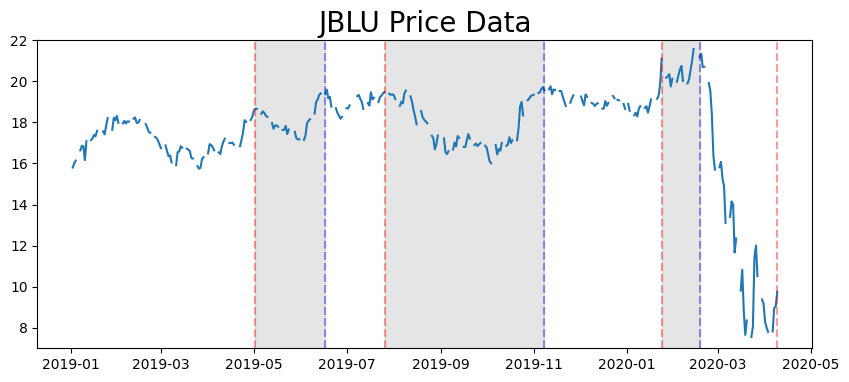

In [44]:
plt.figure(figsize=(10,4))
plt.plot(priceData)

y_lims = (int(priceData.min()*.95), int(priceData.max()*1.05))
shaded_y_lims = int(priceData.min()*.5), int(priceData.max()*1.5)

for idx, event in enumerate(events_list):
    color = 'red' if event[0] == 'b' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
    if event[0] == 's':
        plt.fill_betweenx(range(*shaded_y_lims), 
                          event[1], events_list[idx-1][1], color='k', alpha=0.1)

plt.title("%s Price Data"%tickerSymbol, fontsize=20)
plt.ylim(*y_lims)
plt.show()